In [1]:

import torch
from torch.utils.data import DataLoader

from src.configs import get_avail_splits, get_class_list, set_seed
from src.run_types import (
    AVAIL_SETS,
    AVAIL_SPLITS,
    SEED,
    CentreCropConfig,
    OG_Sampler,
    RandAugConfig,
)
from src.utils import plt_display_grid
from src.video_dataset import VideoDataset, get_transform, get_wlasl_info
from src.visualise2 import set_thesis_style

In [2]:
set_thesis_style()
set_seed(SEED)

## Setup

### Dataset

Available splits:

In [3]:
av_splits = get_avail_splits()
for s in av_splits:
    print(s)

asl100_worst
asl1000
asl2000_cutoff_9
asl100_bottom
asl100
asl300_cutoff_9
asl1000_cutoff_9
asl2000
asl100_cutoff_9
asl300


Chosen split, and set:

In [4]:
split_name: AVAIL_SPLITS = "asl100"
set_name: AVAIL_SETS = "test"
print(split_name, set_name)

asl100 test


Dataset info:

In [5]:
test_info = get_wlasl_info(split_name, set_name)
print(test_info)

{'root': PosixPath('/home/luke/Code/SLR/data/WLASL/WLASL2000'), 'labels': PosixPath('/home/luke/Code/SLR/data/WLASL/preprocessed/labels/asl100'), 'label_suff': 'fixed_frange_bboxes.json', 'set_name': 'test'}


Class list:

In [6]:
class_list = get_class_list()
print(len(class_list))

2000


## RandAugment settings

Compare a control (no RandAugment) crop against the settings this project actually explored for
S3D (see `src/configfiles/RandAug/`): the base `num_ops=2, magnitude=7`, plus the `ops3` and
`mag10` variants.

In [7]:
FRAME_SIZE = 224
TARGET_LENGTH = 32

RandAugSetting = tuple[int, int]  # (num_ops, magnitude)


def build_transform(setting: RandAugSetting | None):
    spatial_aug = [CentreCropConfig(frame_size=FRAME_SIZE)]
    if setting is not None:
        num_ops, magnitude = setting
        spatial_aug.append(
            RandAugConfig(
                type="RANDAUGMENT", num_ops=num_ops, magnitude=magnitude, interpolation="bilinear"
            )
        )

    transform, _, _ = get_transform(
        temporal_aug=[OG_Sampler(target_length=TARGET_LENGTH)],
        spatial_aug=spatial_aug,
        normalise_to_float=False,
        permute_time_channel=False,
    )
    return transform

## Examine frames

Bring a batch's frames into `(T, C, H, W)` order for display.

In [8]:
def prep_frames(batch: dict[str, torch.Tensor]) -> torch.Tensor:
    frames = batch["frames"]
    if frames.dim() == 5:
        frames = frames.squeeze(0)
    if frames.shape[1] != 3:
        frames = frames.permute(1, 0, 2, 3)  # swap T and C
    return frames

## Compare control vs. each setting

`shuffle=False`, so the first item drawn from the loader is always the same clip — only the
transform changes between calls.

In [9]:
def show_setting(label: str, setting: RandAugSetting | None) -> None:
    transform = build_transform(setting)
    dataset = VideoDataset(set_info=test_info, transforms=transform)
    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
    sample = next(iter(loader))
    frames = prep_frames(sample)

    print(f"{label} - class: {class_list[int(sample['label_num'])]}")
    plt_display_grid(frames, TARGET_LENGTH, size=(2, 2), cols=4)

### Control (no RandAugment)

Control - class: book


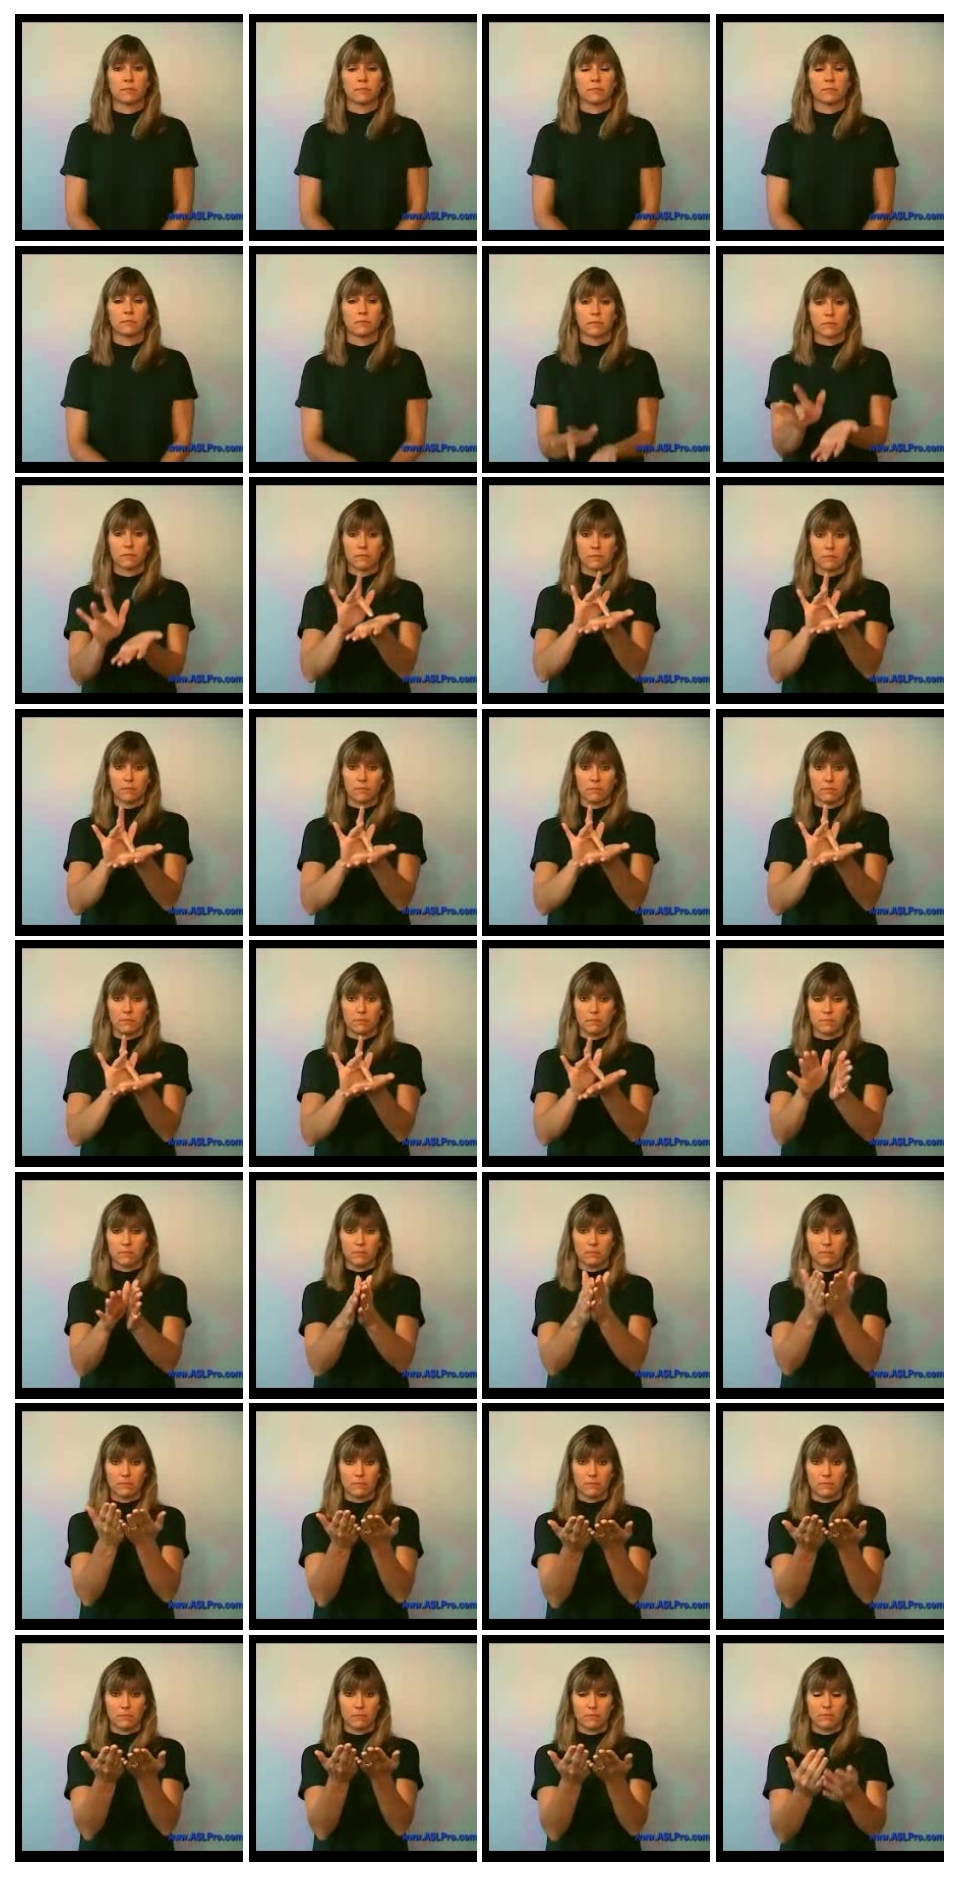

In [10]:
show_setting("Control", None)

### num_ops=2, magnitude=7 (base)

num_ops=2, magnitude=7 - class: book


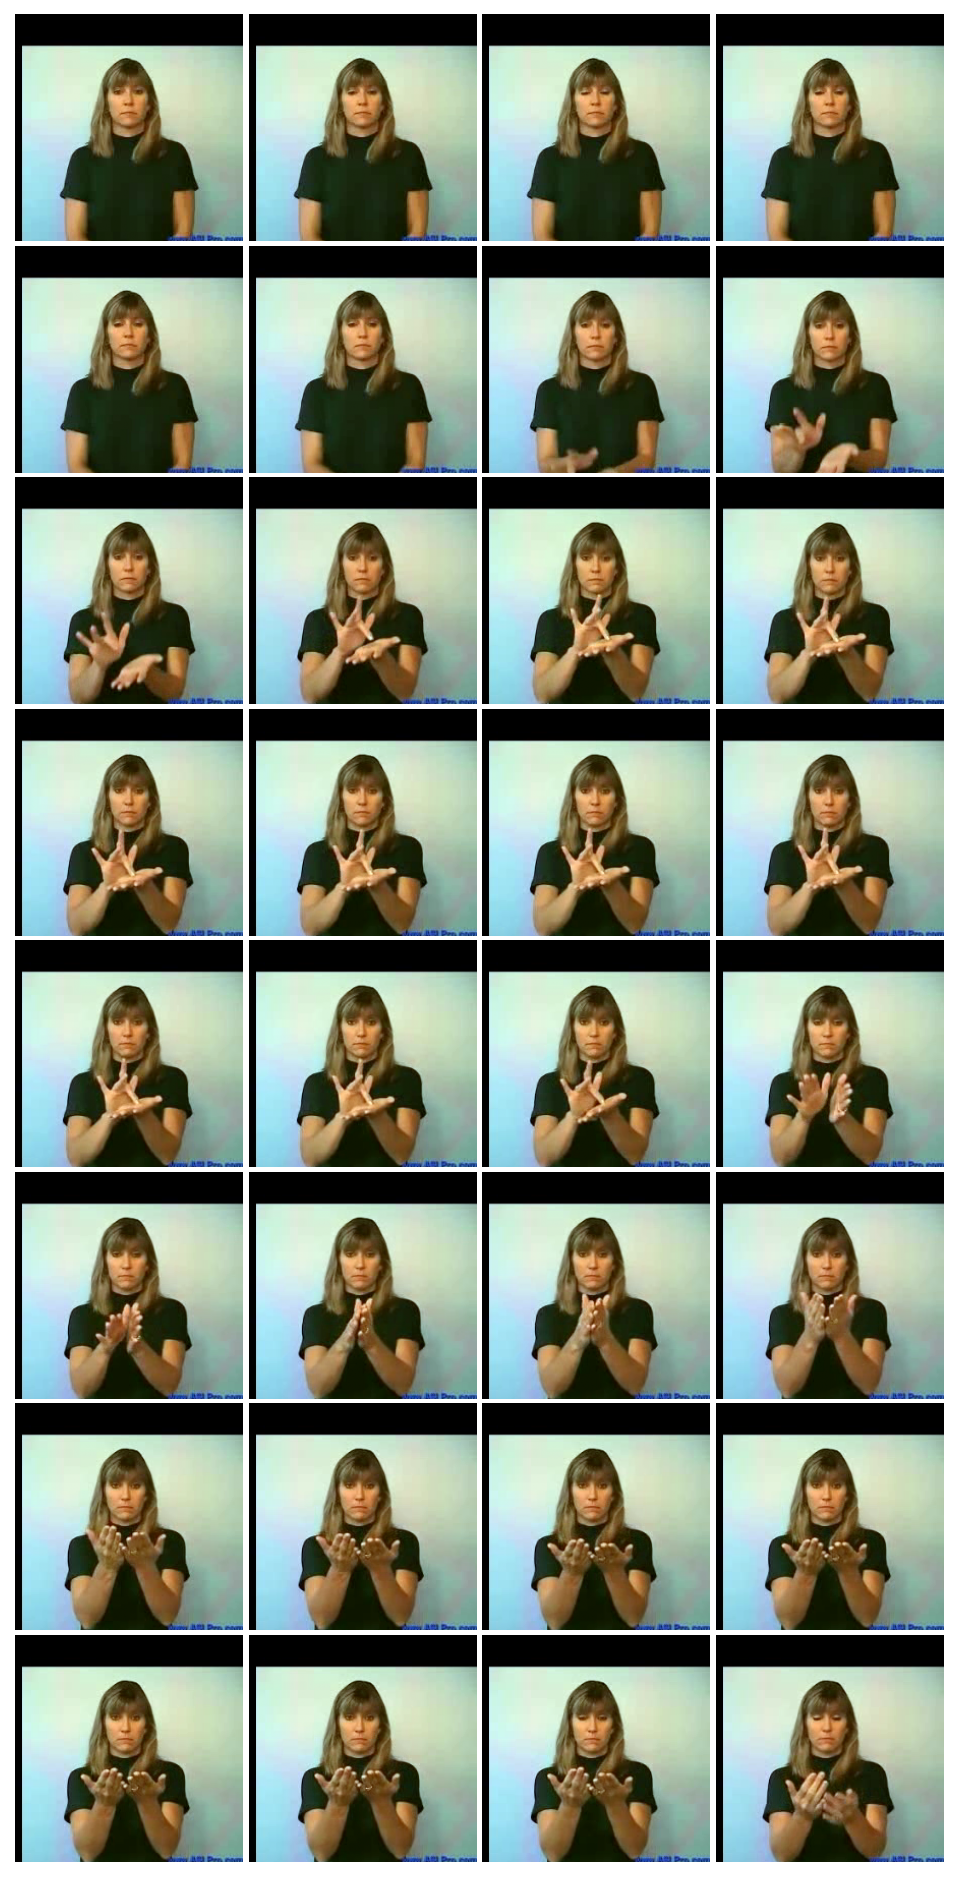

In [11]:
show_setting("num_ops=2, magnitude=7", (2, 7))

### num_ops=3, magnitude=7

num_ops=3, magnitude=7 - class: book


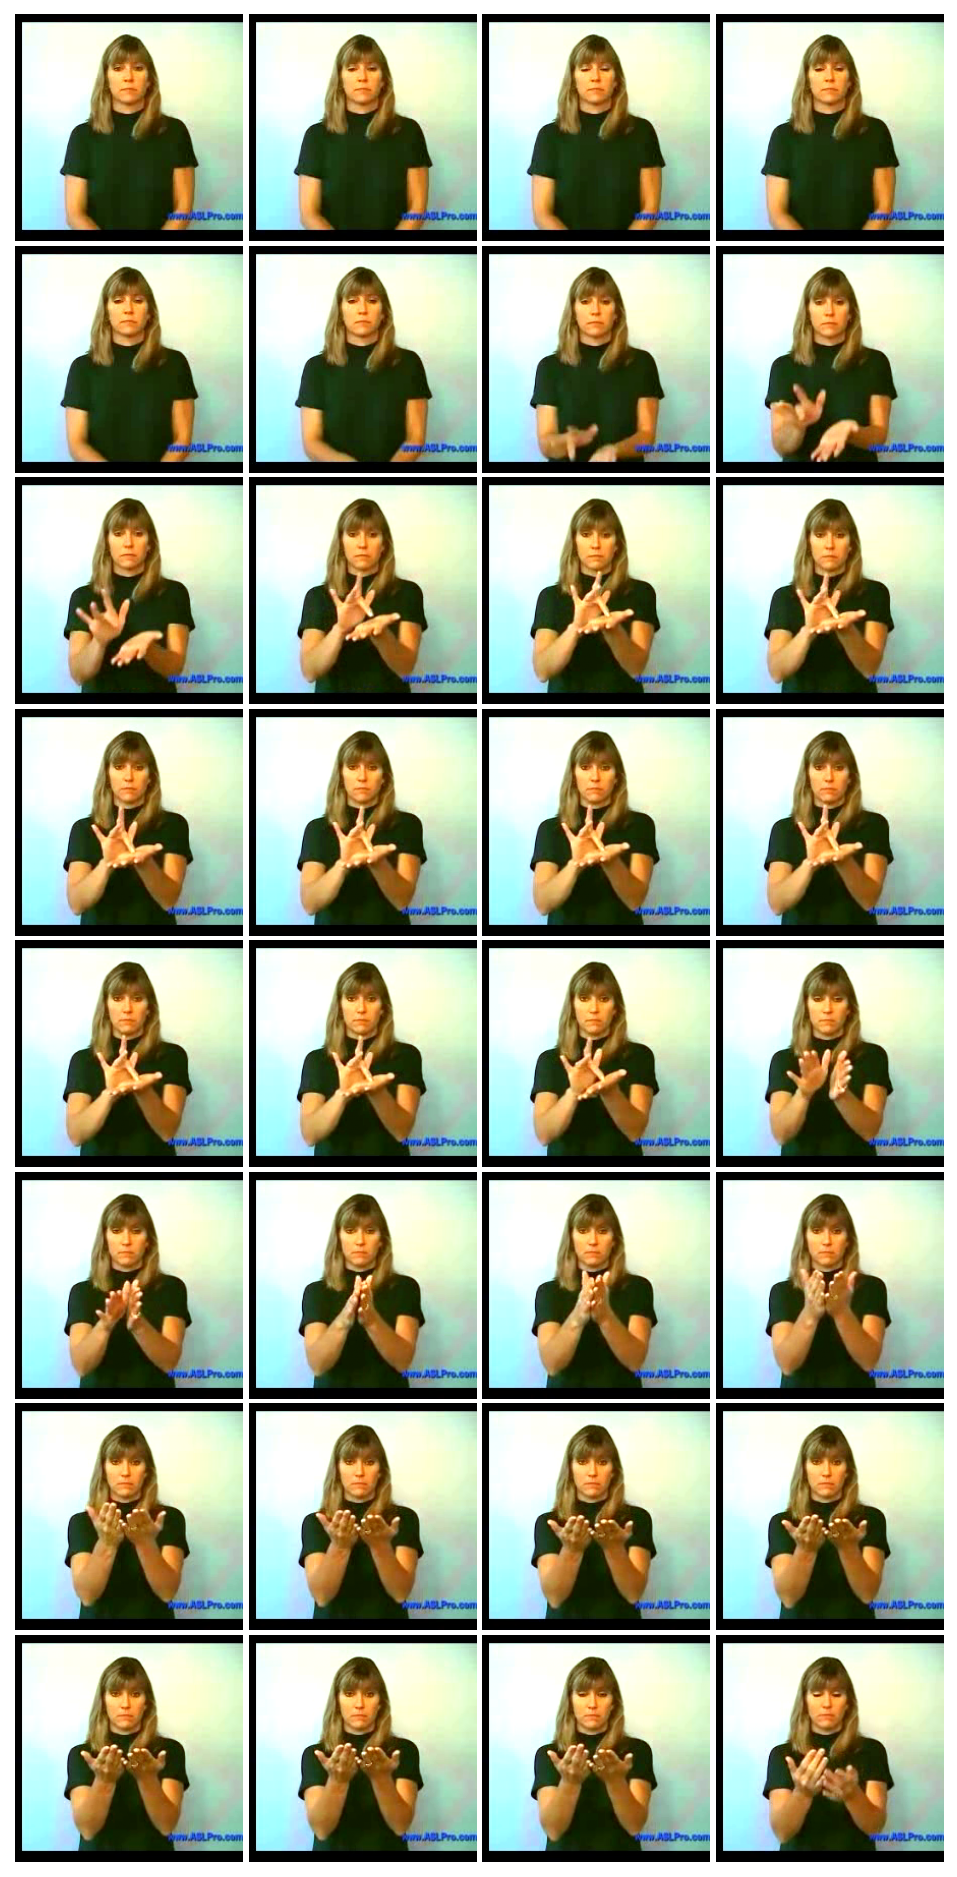

In [12]:
show_setting("num_ops=3, magnitude=7", (3, 7))

### num_ops=2, magnitude=10

num_ops=2, magnitude=10 - class: book


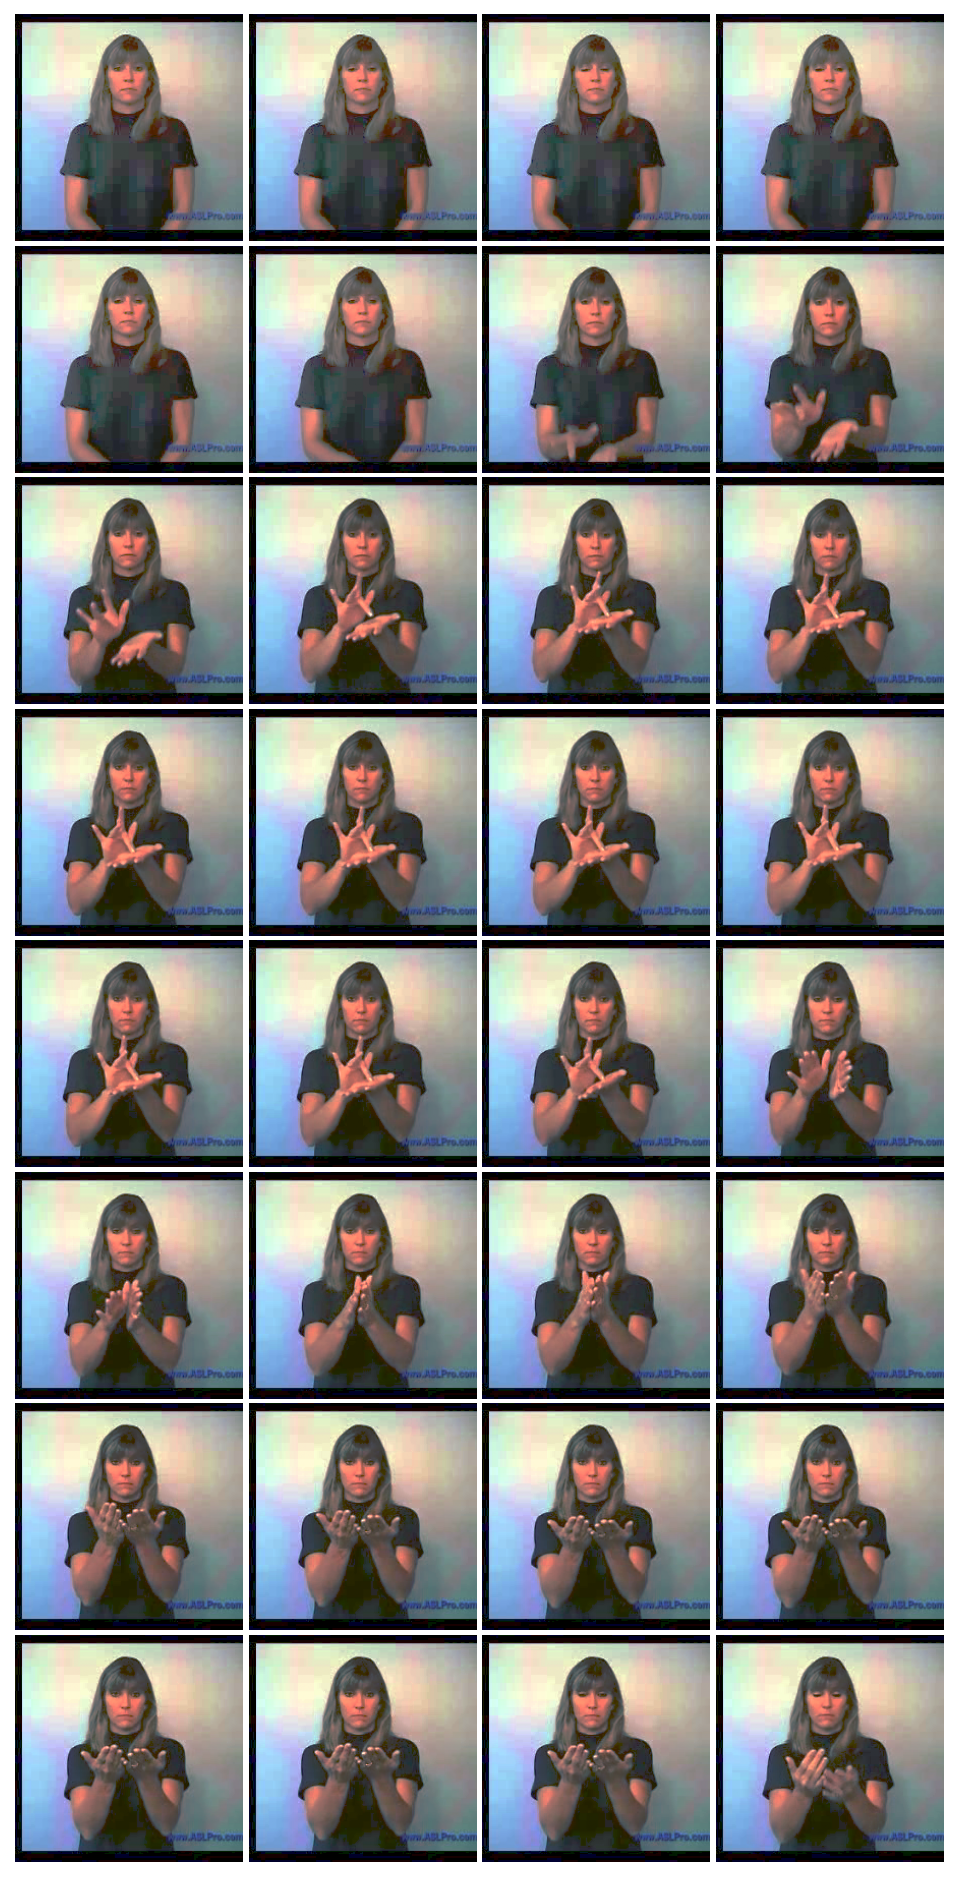

In [13]:
show_setting("num_ops=2, magnitude=10", (2, 10))

# Conclusion

On this clip (asl100 test, class "book"), the project's base RandAugment setting
(`num_ops=2, magnitude=7`) landed on ops that are barely distinguishable from the control crop —
consistent with RandAugment sampling from a bank that includes mild/near-identity ops. Both
`ops3` (`num_ops=3, magnitude=7`) and especially `mag10` (`num_ops=2, magnitude=10`) show a clear,
consistent colour-cast across every sampled frame (warm/green for `ops3`, a strong blue shift for
`mag10`), with `mag10`'s change the most visually dramatic of the three. So on this sample,
raising the magnitude had a bigger visible effect than adding a third op — worth keeping in mind
when picking RandAugment strength for training, since `magnitude` and `num_ops` don't scale the
perturbation equally.